## Column Profiling:


**Time & Marketplace Identifiers**

* **market_id**: Represents the geographic market/location where the order was placed (e.g., city/region served by delivery platform).

* **created_at**: Timestamp when the customer placed the order on the platform.

* **actual_delivery_time**: Timestamp when the food order was actually delivered to the customer.


**Store Information**

* **store_id**: Unique identifier for the restaurant/store preparing the order.

* **store_primary_category**: Type of cuisine or restaurant category (e.g., American, Mexican). Helps understand prep time differences across cuisines.
Example: *american, mexican, asian, fast-food, etc.*

* **order_protocol**: Internal system indicating how a restaurant receives orders (e.g., POS system, manual entry, tablet).
Higher protocol numbers may represent automated or direct-POS integrations.


**Order Details**

* **total_items**: Total number of food items in the order (higher count may increase prep time).

* **subtotal**: Total price (in cents) before taxes, delivery fee, or tip. Indicates order size/value.

* **num_distinct_items**: Number of unique menu items in the order — useful for understanding complexity (more unique items = longer prep time).

* **min_item_price**: Lowest priced item in the order — helps indicate order mix.

* **max_item_price**: Highest priced item — may signal premium or complex dish.


### **Dasher / Delivery Network Status**

* **total_onshift_dashers**: Total delivery drivers (dashers) available in the region at that time.

* **total_busy_dashers**: Number of dashers currently active on deliveries.
Higher value = busier marketplace → longer delivery time possible.

* **total_outstanding_orders**: Number of pending delivery orders in the system.
Shows demand level — high outstanding orders may delay deliveries.


### **Platform Estimated Durations**

* **estimated_order_place_duration**: Estimated time (in seconds) between placing the order and restaurant confirmation.

* **estimated_store_to_consumer_driving_duration**: Estimated driving time (in seconds) from restaurant to customer — based on distance & traffic patterns.



In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
url = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/historical_data.csv'

data = pd.read_csv(url)

In [142]:
data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [143]:
data.shape

(197428, 16)

In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     196441 non-null  float64
 1   created_at                                    197428 non-null  object 
 2   actual_delivery_time                          197421 non-null  object 
 3   store_id                                      197428 non-null  int64  
 4   store_primary_category                        192668 non-null  object 
 5   order_protocol                                196433 non-null  float64
 6   total_items                                   197428 non-null  int64  
 7   subtotal                                      197428 non-null  int64  
 8   num_distinct_items                            197428 non-null  int64  
 9   min_item_price                                19

In [145]:
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     196441 non-null  float64       
 1   created_at                                    197428 non-null  datetime64[ns]
 2   actual_delivery_time                          197421 non-null  datetime64[ns]
 3   store_id                                      197428 non-null  int64         
 4   store_primary_category                        192668 non-null  object        
 5   order_protocol                                196433 non-null  float64       
 6   total_items                                   197428 non-null  int64         
 7   subtotal                                      197428 non-null  int64         
 8   num_distinct_items                            197428 n

In [146]:
data.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [147]:
data.nunique()

,0
market_id,6
created_at,180985
actual_delivery_time,178110
store_id,6743
store_primary_category,74
order_protocol,7
total_items,57
subtotal,8368
num_distinct_items,20
min_item_price,2312


# Data cleaning & EDA

### Imputing Missing Values

In [148]:
data = data.dropna(subset=['actual_delivery_time', 'market_id', 'estimated_store_to_consumer_driving_duration', 'order_protocol'])

data['delivery_duration'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds()
data['hour'] = data['created_at'].dt.hour
data['order_date'] = data['created_at'].dt.date
data['is_weekend'] = (data['created_at'].dt.dayofweek >= 5).astype(int)

data.drop(['actual_delivery_time', 'created_at'], axis=1, inplace=True)

In [149]:
data.isna().sum()

,0
market_id,0
store_id,0
store_primary_category,3995
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0
total_onshift_dashers,16107


In [150]:
data.describe()

,market_id,store_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,hour,is_weekend
count,195402.000000,195402.000000,195402.000000,195402.000000,195402.000000,195402.000000,195402.000000,195402.000000,179295.000000,179295.000000,179295.000000,195402.000000,195402.000000,1.954020e+05,195402.000000,195402.000000
mean,2.978649,3529.889080,2.882243,3.197055,2682.831604,2.671303,686.282950,1159.838738,44.815282,41.751410,58.062422,308.608402,545.320447,2.909452e+03,8.450082,0.346245
std,1.524955,2053.086835,1.503912,2.669754,1823.008553,1.630859,522.180501,558.620980,34.538853,32.158453,52.680403,90.170138,219.329562,1.932839e+04,8.654838,0.475774
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000,0.000000,0.000000,1.010000e+02,0.000000,0.000000
25%,2.000000,1686.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000,251.000000,382.000000,2.105000e+03,2.000000,0.000000
50%,3.000000,3589.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000,251.000000,544.000000,2.661000e+03,3.000000,0.000000
75%,4.000000,5298.000000,4.000000,4.000000,3396.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000,446.000000,702.000000,3.382000e+03,19.000000,1.000000
max,6.000000,6987.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000,2715.000000,2088.000000,8.516859e+06,23.000000,1.000000


In [151]:
data.shape

(195402, 18)

In [152]:
data.isna().sum()

,0
market_id,0
store_id,0
store_primary_category,3995
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0
total_onshift_dashers,16107


In [153]:
(data['total_onshift_dashers'].isna() == data['total_busy_dashers'].isna()).all()

np.True_

In [154]:
(data['total_onshift_dashers'].isna() == data['total_outstanding_orders'].isna()).all()

np.True_

In [155]:
print(data.groupby('market_id')['total_onshift_dashers'].median())
print(data.groupby('market_id')['total_busy_dashers'].median())
print(data.groupby('market_id')['total_outstanding_orders'].median())

market_id
1.0    19.0
2.0    55.0
3.0    15.0
4.0    60.0
5.0    20.0
6.0    36.0
Name: total_onshift_dashers, dtype: float64
market_id
1.0    18.0
2.0    54.0
3.0    13.0
4.0    57.0
5.0    16.0
6.0    35.0
Name: total_busy_dashers, dtype: float64
market_id
1.0    22.0
2.0    69.0
3.0    14.0
4.0    74.0
5.0    20.0
6.0    43.0
Name: total_outstanding_orders, dtype: float64


In [156]:
data['total_onshift_dashers'] = data['total_onshift_dashers'].fillna(data.groupby('market_id')['total_onshift_dashers'].transform('median'))
data['total_busy_dashers'] = data['total_busy_dashers'].fillna(data.groupby('market_id')['total_busy_dashers'].transform('median'))
data['total_outstanding_orders'] = data['total_outstanding_orders'].fillna(data.groupby('market_id')['total_outstanding_orders'].transform('median'))

In [157]:
data['store_primary_category'] = data['store_primary_category'].fillna('Unknown')

In [158]:
data.isna().sum()

,0
market_id,0
store_id,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0
total_onshift_dashers,0


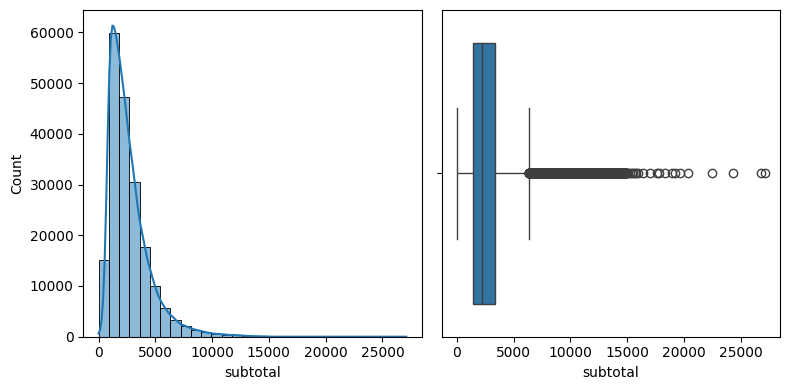

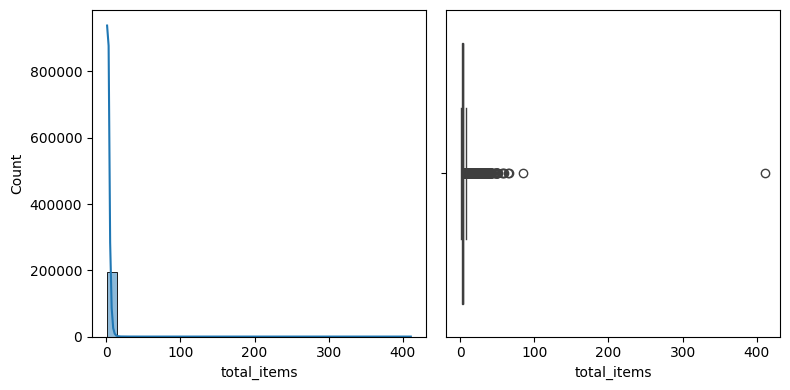

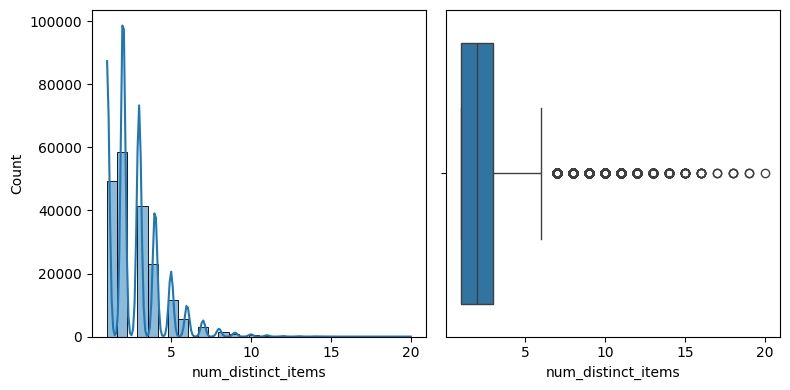

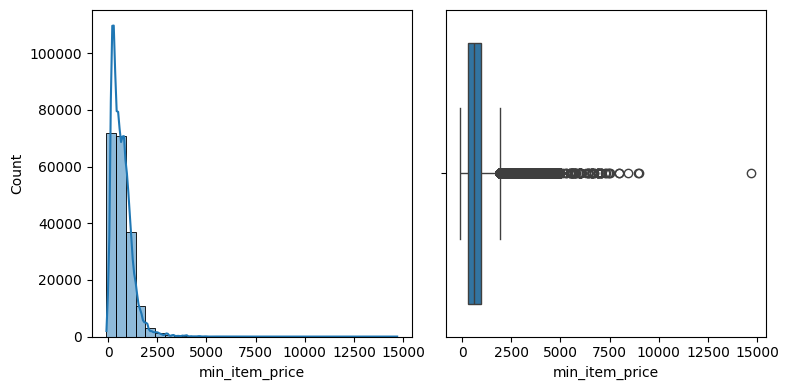

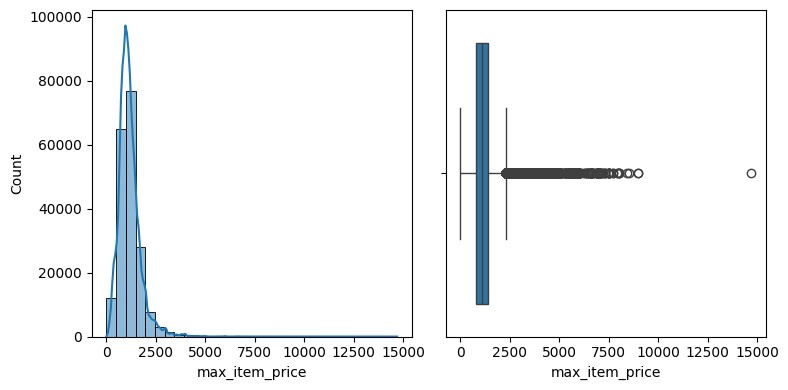

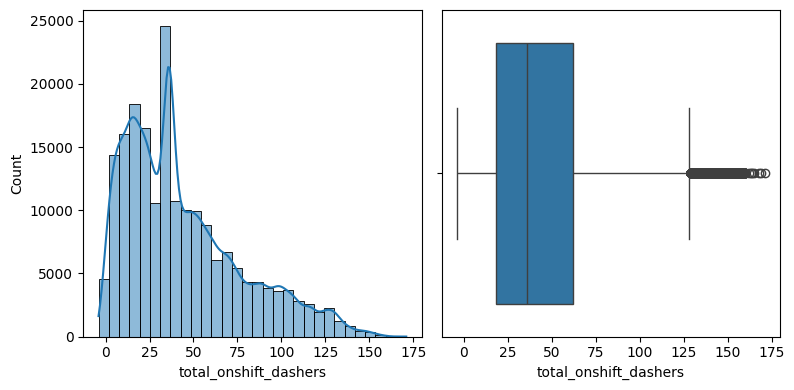

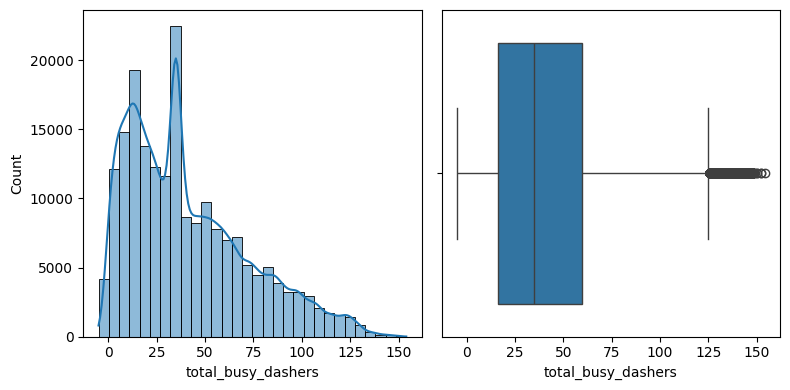

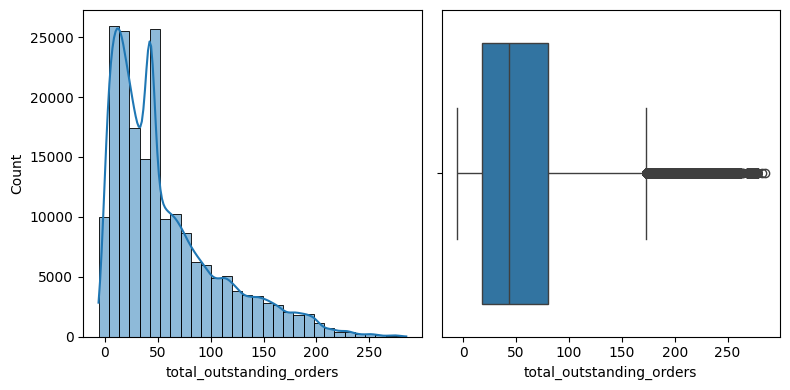

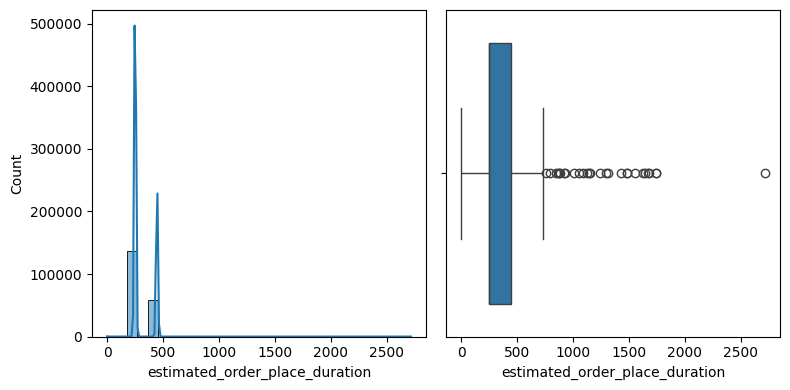

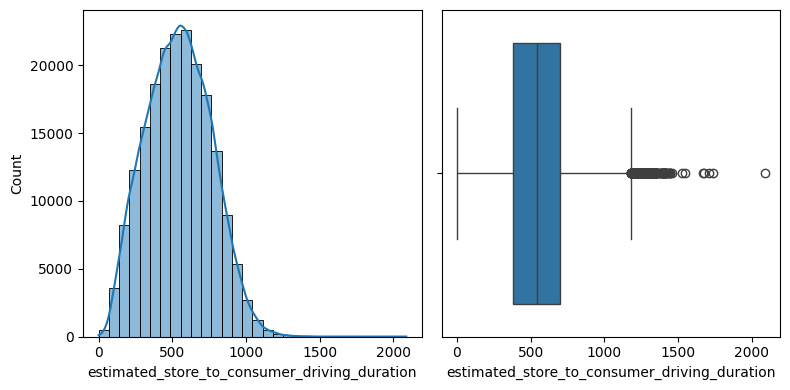

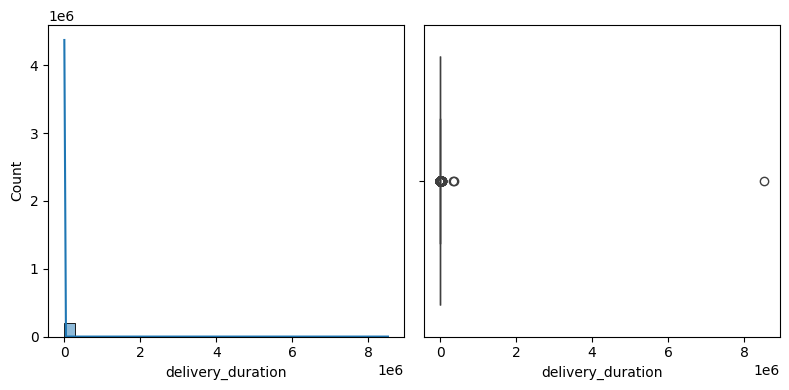

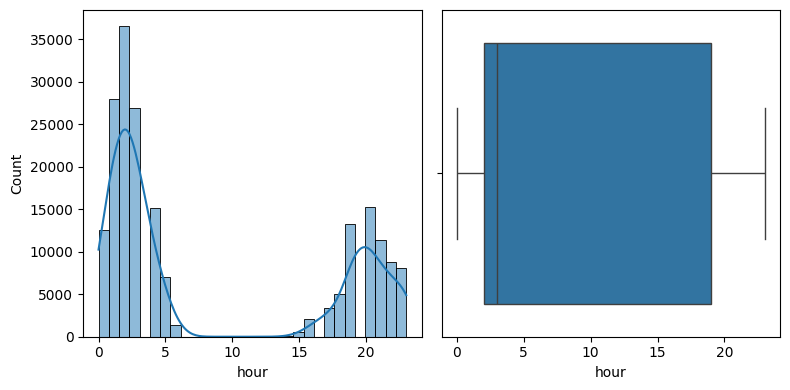

In [159]:
continuous_cols = [
    "subtotal",
    "total_items",
    "num_distinct_items",
    "min_item_price",
    "max_item_price",
    "total_onshift_dashers",
    "total_busy_dashers",
    "total_outstanding_orders",
    "estimated_order_place_duration",
    "estimated_store_to_consumer_driving_duration",
    'delivery_duration',
    'hour'
]

for cols in continuous_cols:
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    sns.histplot(data[cols], kde=True, bins=30)

    plt.subplot(1,2,2)
    sns.boxplot(x=data[cols])
    plt.tight_layout()
    plt.show()

<Axes: xlabel='is_weekend', ylabel='count'>

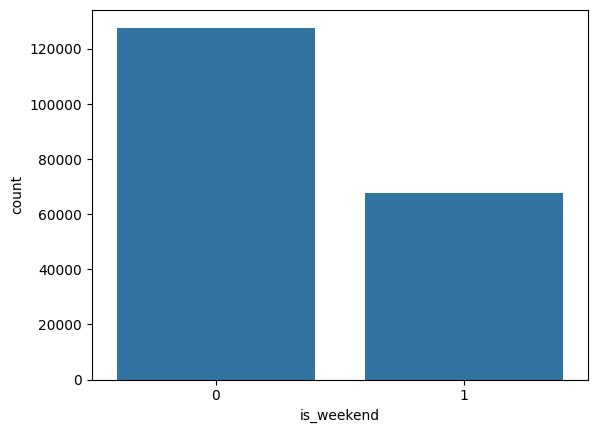

In [160]:
sns.countplot(data=data, x='is_weekend')

<Axes: xlabel='hour', ylabel='delivery_duration'>

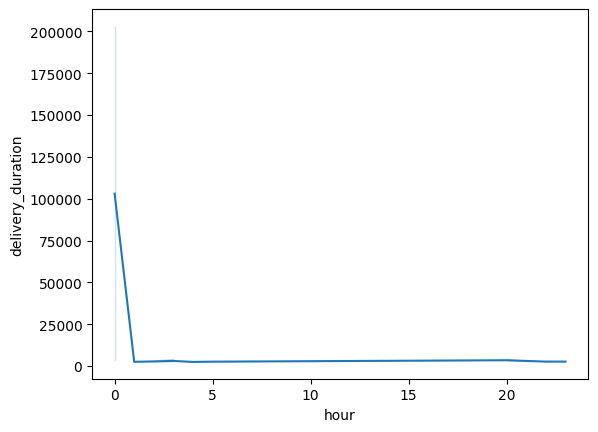

In [161]:
sns.lineplot(data=data, x='hour', y=data.groupby('hour')['delivery_duration'].mean())

<Axes: xlabel='delivery_duration'>

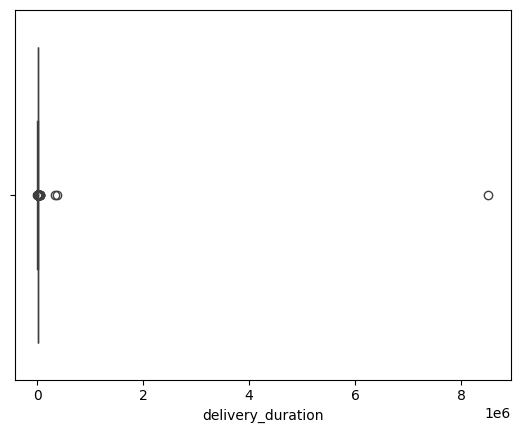

In [162]:
sns.boxplot(data=data, x='delivery_duration')


In [163]:
data['delivery_duration'].sort_values(ascending=False).head(30)

,delivery_duration
2690,8516859.0
185550,373879.0
27189,332482.0
83055,57032.0
190860,54447.0
86952,48178.0
76743,45685.0
105825,39352.0
66787,38457.0
175971,38143.0


In [164]:
data = data[data['delivery_duration'] <= 21600]
data = data[data['delivery_duration'] <= 21600].copy()

<Axes: xlabel='delivery_duration'>

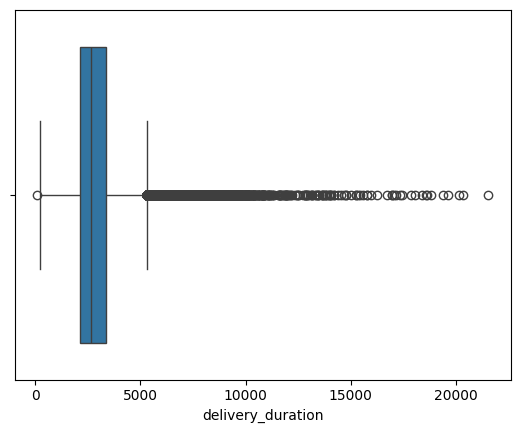

In [165]:
sns.boxplot(data=data, x='delivery_duration')


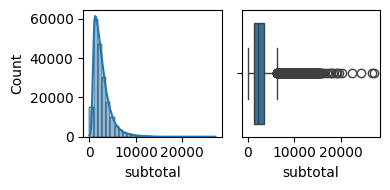

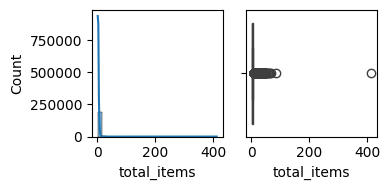

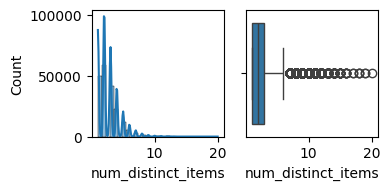

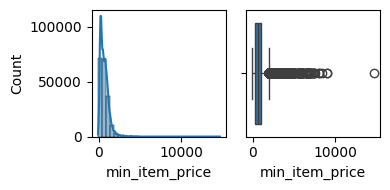

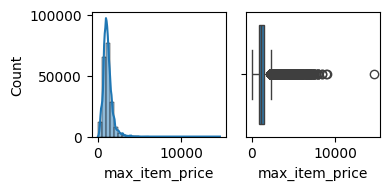

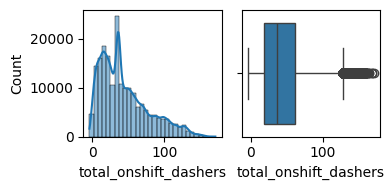

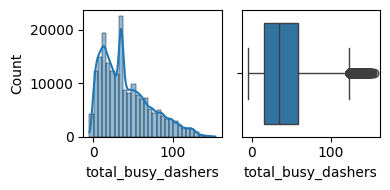

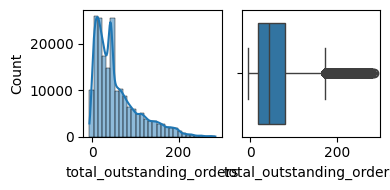

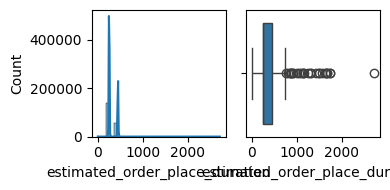

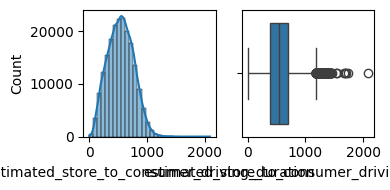

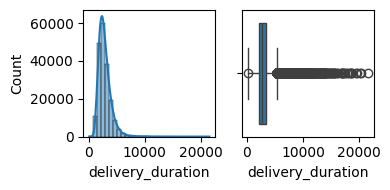

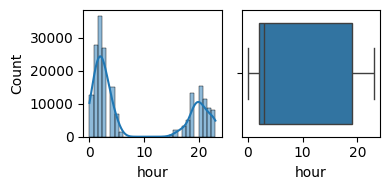

In [166]:
continuous_cols = [
    "subtotal",
    "total_items",
    "num_distinct_items",
    "min_item_price",
    "max_item_price",
    "total_onshift_dashers",
    "total_busy_dashers",
    "total_outstanding_orders",
    "estimated_order_place_duration",
    "estimated_store_to_consumer_driving_duration",
    'delivery_duration',
    'hour'
]

for cols in continuous_cols:
    plt.figure(figsize=(4,2))

    plt.subplot(1,2,1)
    sns.histplot(data[cols], kde=True, bins=30)

    plt.subplot(1,2,2)
    sns.boxplot(x=data[cols])
    plt.tight_layout()
    plt.show()

In [167]:
data.loc[data['total_items'].nlargest(5).index]

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,hour,order_date,is_weekend
47231,2.0,777,fast,4.0,411,3115,5,0,299,35.0,35.0,39.0,251,573.0,3055.0,0,2015-02-06,0
182223,6.0,1862,fast,4.0,84,1016,4,0,289,36.0,35.0,43.0,251,581.0,4478.0,19,2015-02-15,1
182800,2.0,6931,fast,4.0,66,1634,6,0,499,30.0,28.0,32.0,251,389.0,1762.0,5,2015-02-18,0
182796,2.0,6931,fast,4.0,64,1166,4,0,499,28.0,19.0,21.0,251,389.0,1736.0,5,2015-02-17,0
75577,1.0,933,fast,4.0,59,2911,3,0,329,25.0,19.0,20.0,251,470.0,2085.0,4,2015-01-23,0


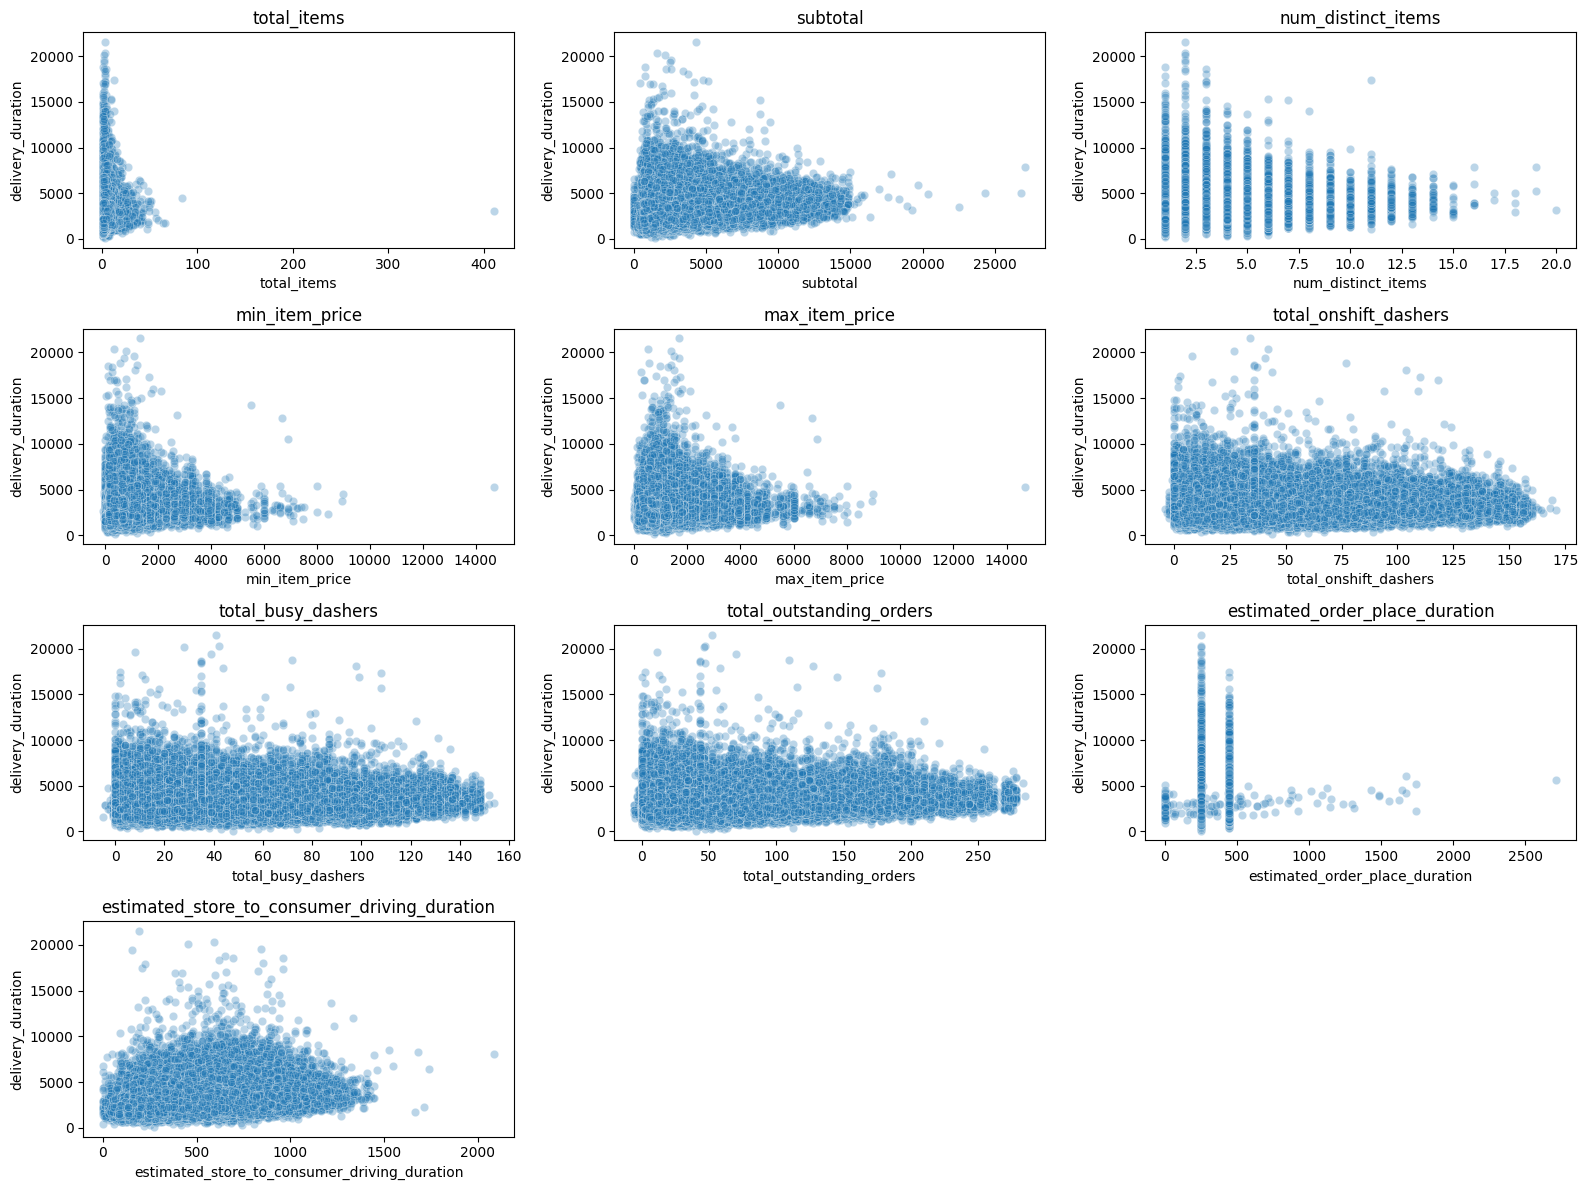

In [168]:
features = ['total_items', 'subtotal', 'num_distinct_items', 'min_item_price',
       'max_item_price', 'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders', 'estimated_order_place_duration',
       'estimated_store_to_consumer_driving_duration']

plt.figure(figsize=(16,12))

for i, col in enumerate(features, 1):
    plt.subplot(4,3,i)
    sns.scatterplot(
        data=data,
        x=col,
        y='delivery_duration',
        alpha=0.3
    )
    plt.title(col)

plt.tight_layout()
plt.show()


In [169]:
cols = ['subtotal', 'total_items', 'num_distinct_items', 'min_item_price', 'max_item_price', 'estimated_store_to_consumer_driving_duration']

In [170]:
data = data[data['min_item_price'] >= 0]

In [171]:
for col in cols:
    print(col)
    print("min:", data[col].min())
    print("num <= -1:", (data[col] <= -1).sum())
    print("num NaN:", data[col].isna().sum())
    print("-" * 30)

subtotal
min: 0
num <= -1: 0
num NaN: 0
------------------------------
total_items
min: 1
num <= -1: 0
num NaN: 0
------------------------------
num_distinct_items
min: 1
num <= -1: 0
num NaN: 0
------------------------------
min_item_price
min: 0
num <= -1: 0
num NaN: 0
------------------------------
max_item_price
min: 0
num <= -1: 0
num NaN: 0
------------------------------
estimated_store_to_consumer_driving_duration
min: 0.0
num <= -1: 0
num NaN: 0
------------------------------


In [172]:
for col in cols:
    data[col] = np.log1p(data[col])

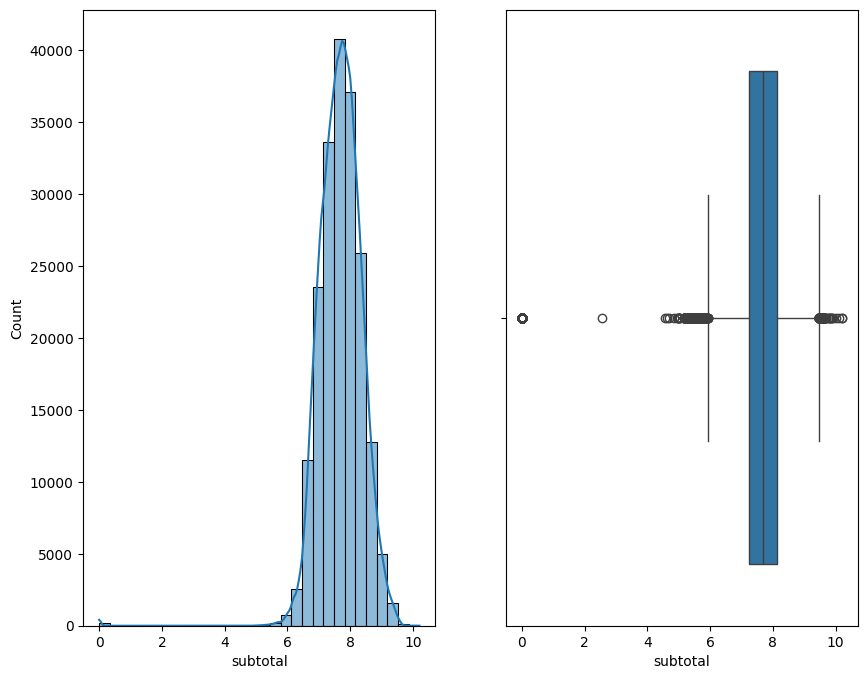

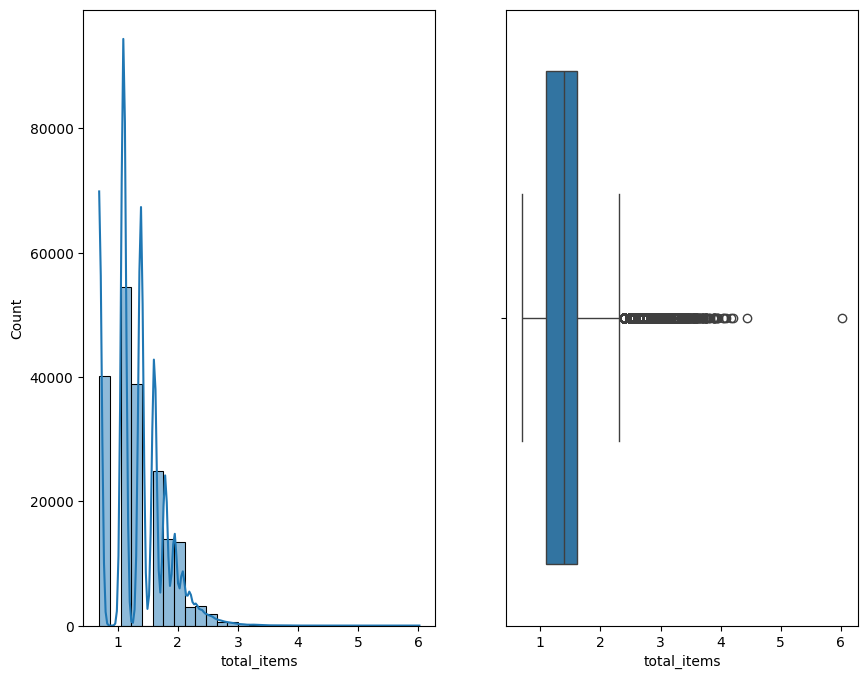

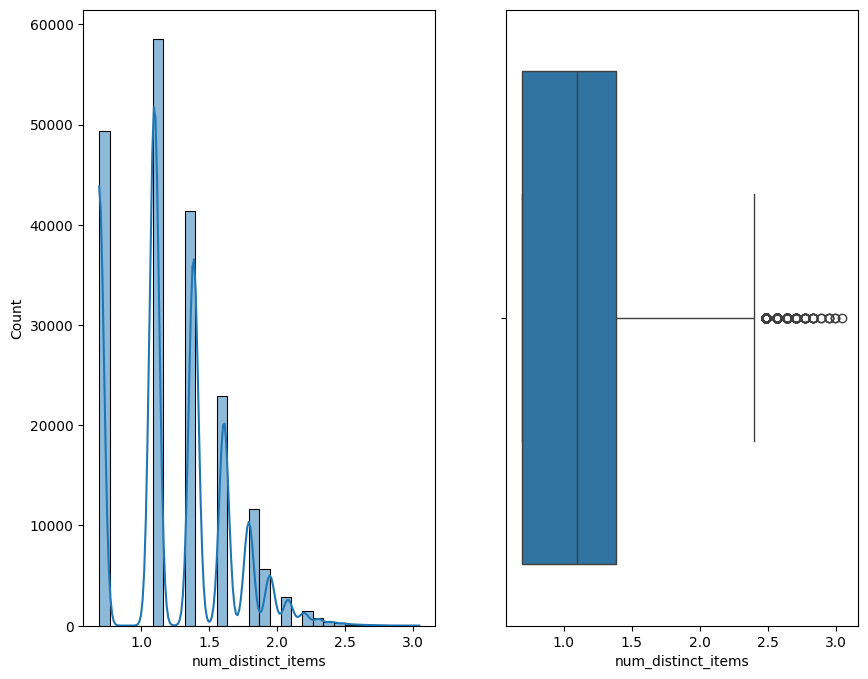

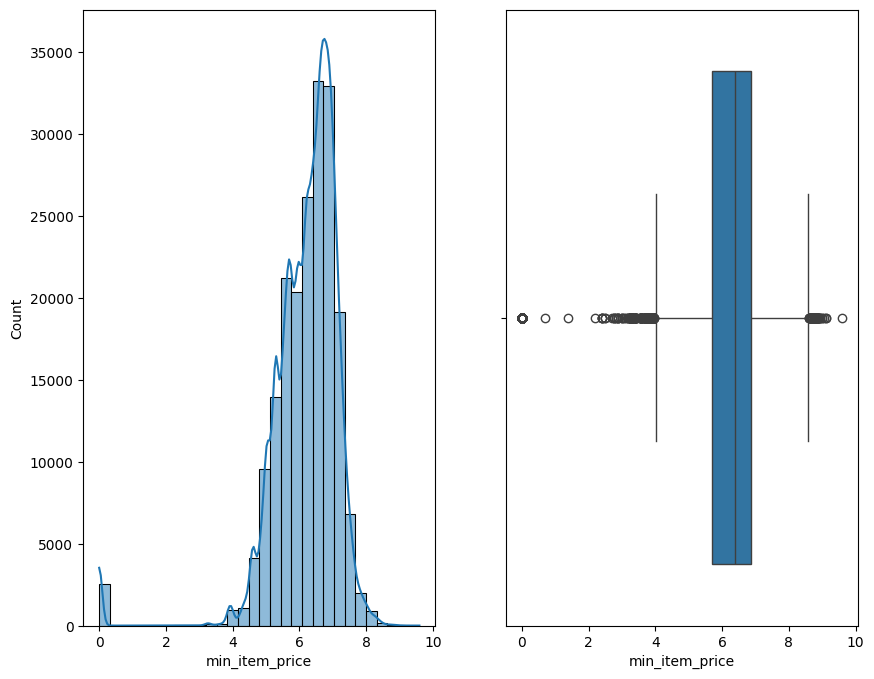

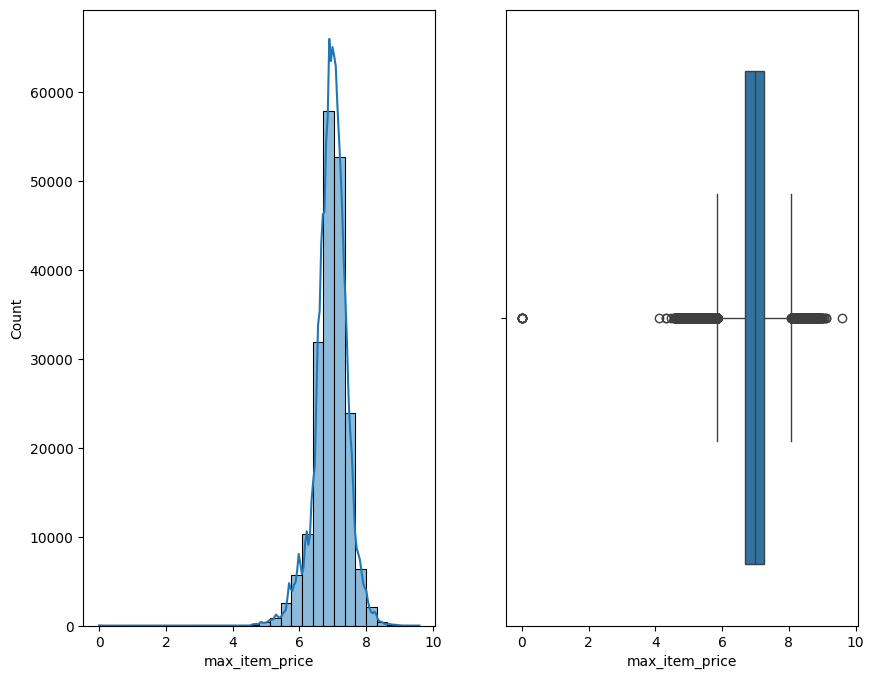

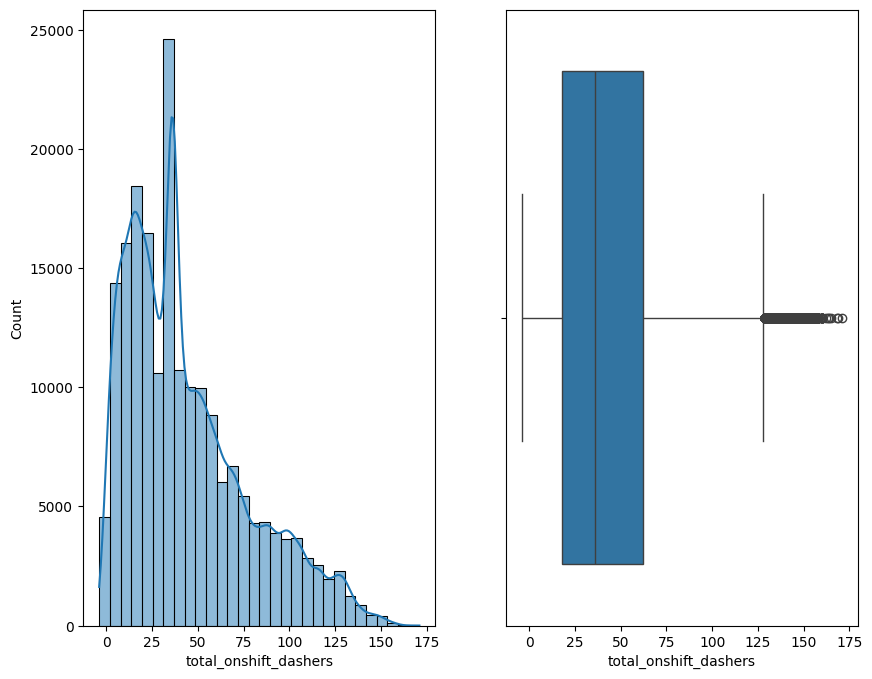

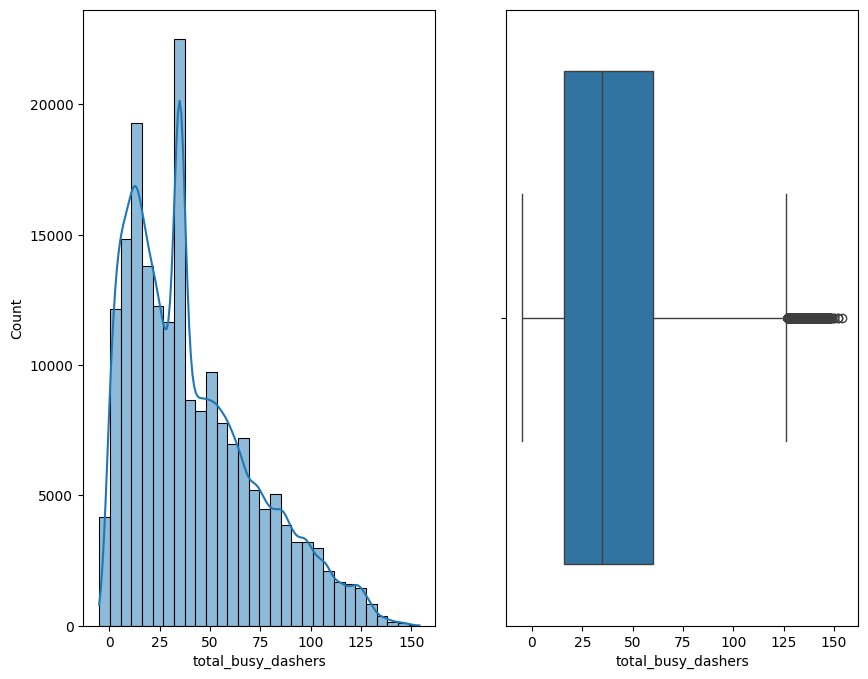

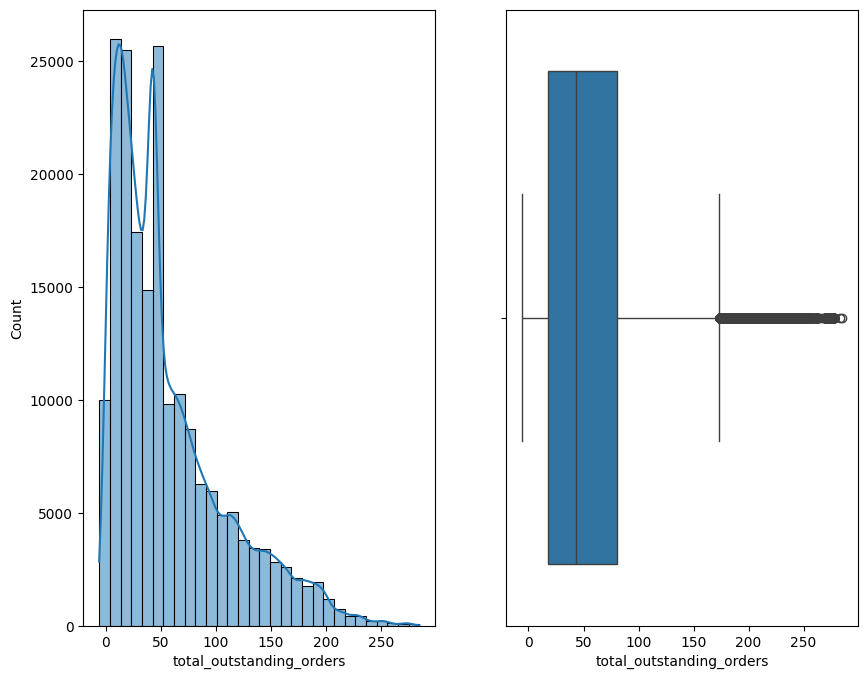

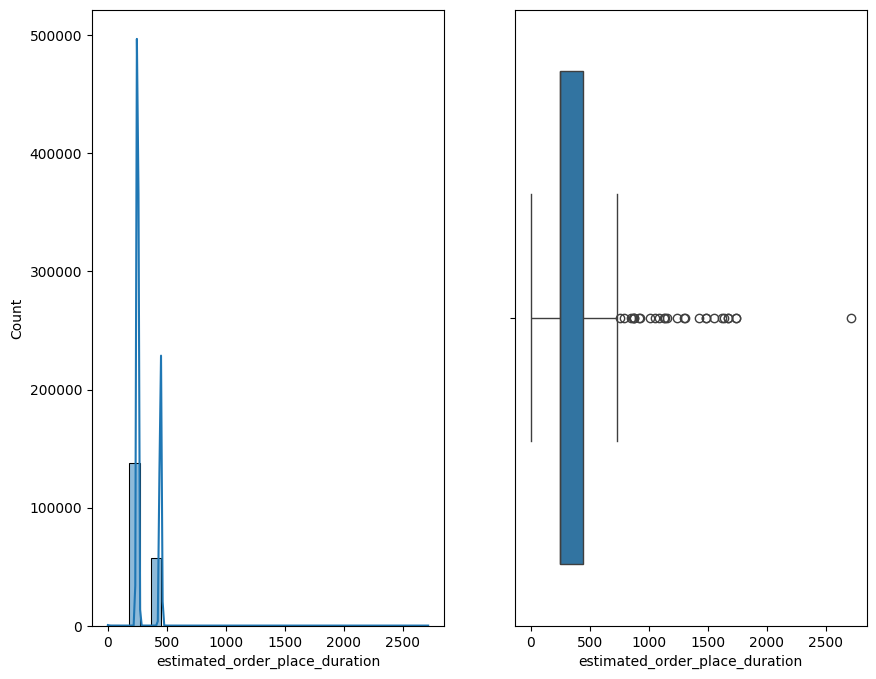

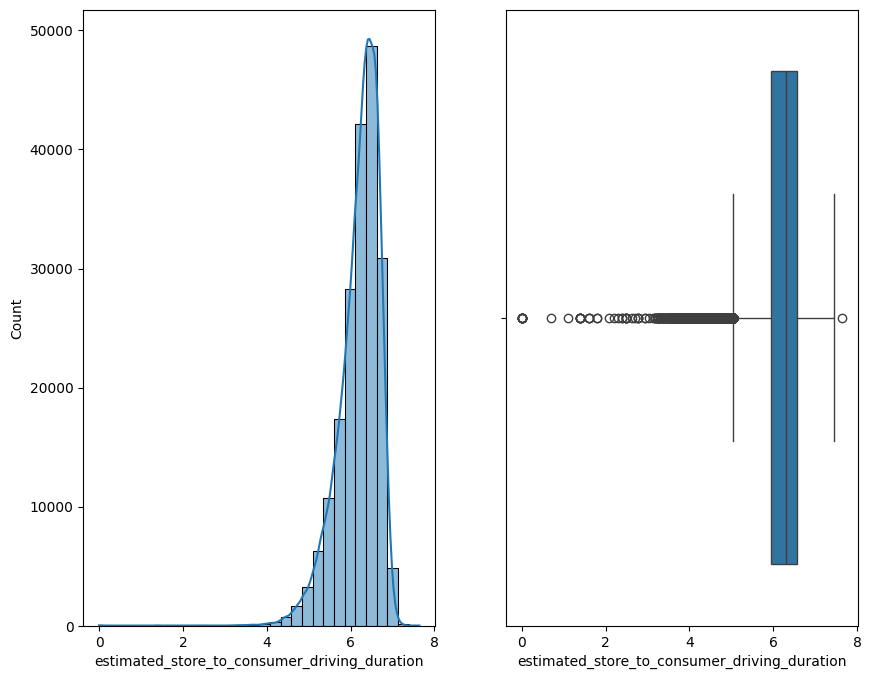

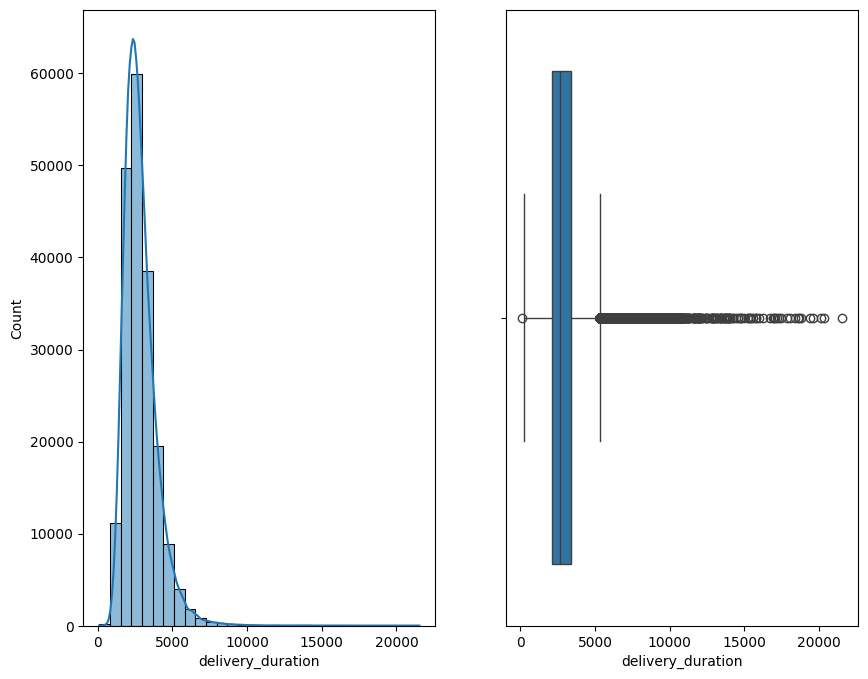

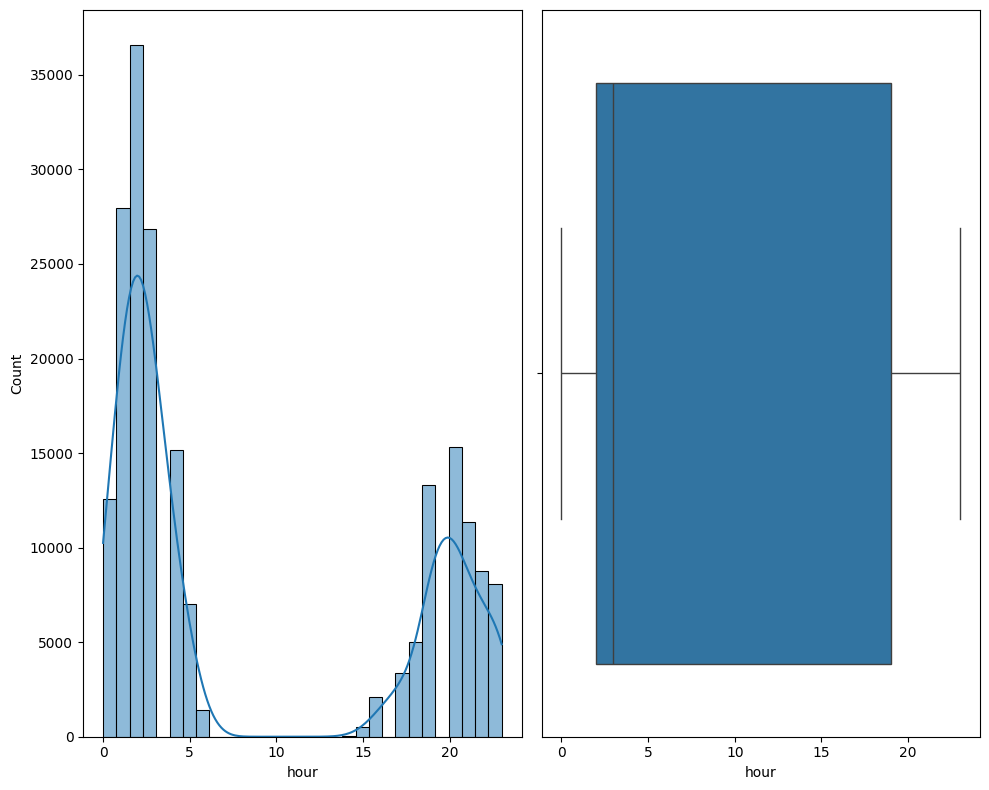

In [173]:
continuous_cols = [
    "subtotal",
    "total_items",
    "num_distinct_items",
    "min_item_price",
    "max_item_price",
    "total_onshift_dashers",
    "total_busy_dashers",
    "total_outstanding_orders",
    "estimated_order_place_duration",
    "estimated_store_to_consumer_driving_duration",
    'delivery_duration',
    'hour'
]

for cols in continuous_cols:
    plt.figure(figsize=(10,8))

    plt.subplot(1,2,1)
    sns.histplot(data[cols], kde=True, bins=30)

    plt.subplot(1,2,2)
    sns.boxplot(x=data[cols])
plt.tight_layout()
plt.show()

<Axes: >

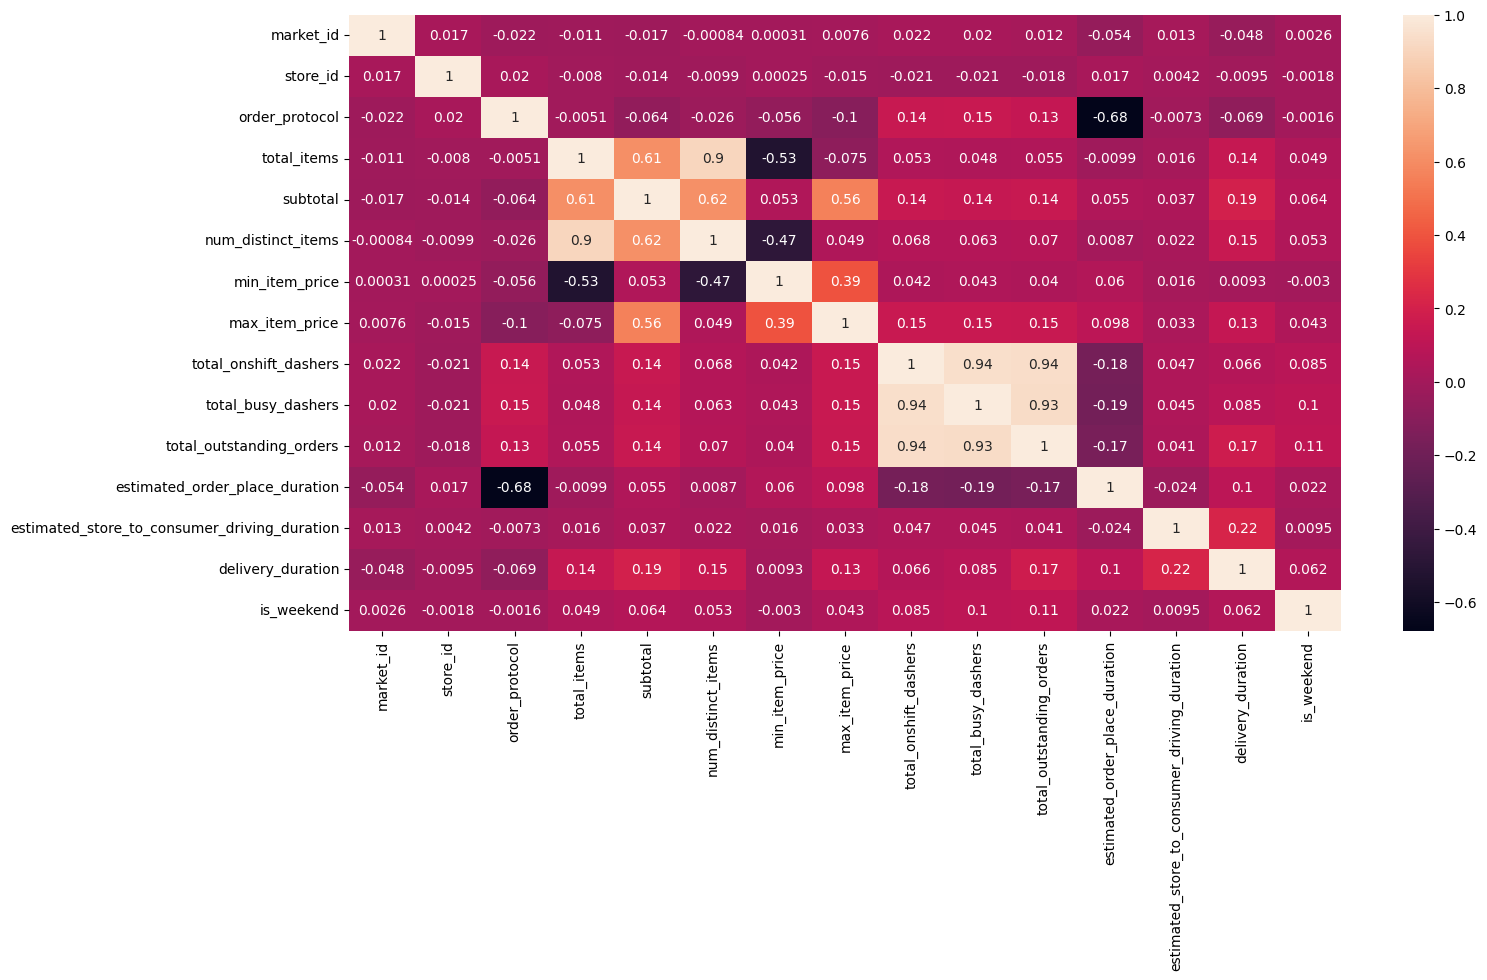

In [174]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, annot=True)

In [175]:
data.shape

(195364, 18)

In [176]:
print("SHAPE:", data.shape)
print("\nTARGET CHECK:")
print(data['delivery_duration'].describe())

print("\nMISSING VALUES (non-zero only):")
print(data.isna().sum()[data.isna().sum() > 0])

print("\nDATA TYPES:")
print(data.dtypes.value_counts())

print("\nNON-NUMERIC COLUMNS LEFT:")
print(data.select_dtypes(exclude=['int64', 'float64']).columns.tolist())

print("\nINFINITE VALUES:")
print(np.isinf(data.select_dtypes(include=[np.number])).sum().sum())

print("\nDUPLICATE ROWS:", data.duplicated().sum())

print("\nFEATURE SCALE SNAPSHOT (min / max):")
data.select_dtypes(include=[np.number]).agg(['min', 'max']).T.head(10)

print("\nCORRELATION WITH TARGET (top & bottom):")
corr = data.select_dtypes(include=[np.number]).corr()['delivery_duration']
print("Top positive:")
print(corr.sort_values(ascending=False).head(8))
print("\nTop negative:")
print(corr.sort_values().head(8))


SHAPE: (195364, 18)

TARGET CHECK:
count    195364.000000
mean       2858.905259
std        1114.814238
min         101.000000
25%        2105.000000
50%        2661.000000
75%        3382.000000
max       21536.000000
Name: delivery_duration, dtype: float64

MISSING VALUES (non-zero only):
Series([], dtype: int64)

DATA TYPES:
float64    12
int64       3
object      2
int32       1
Name: count, dtype: int64

NON-NUMERIC COLUMNS LEFT:
['store_primary_category', 'hour', 'order_date']

INFINITE VALUES:
0

DUPLICATE ROWS: 0

FEATURE SCALE SNAPSHOT (min / max):

CORRELATION WITH TARGET (top & bottom):
Top positive:
delivery_duration                               1.000000
estimated_store_to_consumer_driving_duration    0.218963
subtotal                                        0.194475
total_outstanding_orders                        0.171824
num_distinct_items                              0.146921
total_items                                     0.137165
max_item_price                         

### Data Preprocessing

In [177]:
data.head()

,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,delivery_duration,hour,order_date,is_weekend
0,1.0,1845,american,1.0,1.609438,8.143808,1.609438,6.324359,7.122867,33.0,14.0,21.0,446,6.759255,3779.0,22,2015-02-06,0
1,2.0,5477,mexican,2.0,0.693147,7.550135,0.693147,7.244942,7.244942,1.0,2.0,2.0,446,6.538140,4024.0,21,2015-02-10,0
2,3.0,5477,Unknown,1.0,0.693147,7.550135,0.693147,7.550135,7.550135,1.0,0.0,0.0,446,6.538140,1781.0,20,2015-01-22,0
3,3.0,5477,Unknown,1.0,1.945910,8.839422,1.791759,6.398595,7.496097,1.0,1.0,2.0,446,5.669881,3075.0,21,2015-02-03,0
4,3.0,5477,Unknown,1.0,1.386294,8.268988,1.386294,7.003974,7.378384,6.0,6.0,9.0,446,6.478510,2390.0,2,2015-02-15,1


In [178]:
data['store_primary_category'].nunique()

75

In [179]:
data = pd.get_dummies(data, columns=['store_primary_category'], drop_first=True)

In [180]:
data = pd.get_dummies(data, columns=['order_protocol'], drop_first=True)

In [181]:
data.head()

,market_id,store_id,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,...,store_primary_category_turkish,store_primary_category_vegan,store_primary_category_vegetarian,store_primary_category_vietnamese,order_protocol_2.0,order_protocol_3.0,order_protocol_4.0,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0
0,1.0,1845,1.609438,8.143808,1.609438,6.324359,7.122867,33.0,14.0,21.0,...,False,False,False,False,False,False,False,False,False,False
1,2.0,5477,0.693147,7.550135,0.693147,7.244942,7.244942,1.0,2.0,2.0,...,False,False,False,False,True,False,False,False,False,False
2,3.0,5477,0.693147,7.550135,0.693147,7.550135,7.550135,1.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,5477,1.945910,8.839422,1.791759,6.398595,7.496097,1.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,False
4,3.0,5477,1.386294,8.268988,1.386294,7.003974,7.378384,6.0,6.0,9.0,...,False,False,False,False,False,False,False,False,False,False


In [182]:
data['market_id'] = data['market_id'].astype('category')
data = pd.get_dummies(data, columns=['market_id'], drop_first=True)

In [183]:
data.drop(columns=['store_id'])

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration,...,order_protocol_3.0,order_protocol_4.0,order_protocol_5.0,order_protocol_6.0,order_protocol_7.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0
0,1.609438,8.143808,1.609438,6.324359,7.122867,33.0,14.0,21.0,446,6.759255,...,False,False,False,False,False,False,False,False,False,False
1,0.693147,7.550135,0.693147,7.244942,7.244942,1.0,2.0,2.0,446,6.538140,...,False,False,False,False,False,True,False,False,False,False
2,0.693147,7.550135,0.693147,7.550135,7.550135,1.0,0.0,0.0,446,6.538140,...,False,False,False,False,False,False,True,False,False,False
3,1.945910,8.839422,1.791759,6.398595,7.496097,1.0,1.0,2.0,446,5.669881,...,False,False,False,False,False,False,True,False,False,False
4,1.386294,8.268988,1.386294,7.003974,7.378384,6.0,6.0,9.0,446,6.478510,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197423,1.386294,7.237059,1.386294,5.846439,6.476972,17.0,17.0,23.0,251,5.805135,...,False,True,False,False,False,False,False,False,False,False
197424,1.945910,8.010028,1.609438,6.006353,6.716595,12.0,11.0,14.0,251,6.820016,...,False,True,False,False,False,False,False,False,False,False
197425,1.791759,7.515889,1.386294,5.707110,5.991465,39.0,41.0,40.0,251,6.679599,...,False,True,False,False,False,False,False,False,False,False
197426,0.693147,7.069874,0.693147,6.284134,6.284134,7.0,7.0,12.0,446,5.953243,...,False,False,False,False,False,False,False,False,False,False


In [184]:
data = data.drop(
    columns=['created_at', 'actual_delivery_time', 'order_date'],
    errors='ignore'
)

### Linear Regression

In [185]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [186]:
data['delivery_duration']

,delivery_duration
0,3779.0
1,4024.0
2,1781.0
3,3075.0
4,2390.0
...,...
197423,3907.0
197424,3383.0
197425,3008.0
197426,3907.0


In [187]:
X = data.drop('delivery_duration', axis=1)
y = data['delivery_duration']

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [189]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [190]:
X_train_scaled.shape

(156291, 98)

In [191]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train_scaled, y_train)

LinearRegression(n_jobs=-1)

In [192]:
def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [193]:
y_pred = lr.predict(X_test_scaled)
evaluate_model(y_test, y_pred)

{'MAE': 700.2418268694476, 'RMSE': 955597.2786937272, 'R2': 0.2318088129088779}

### Decision Tree

In [194]:
from sklearn.tree import DecisionTreeRegressor

In [195]:
dtr = DecisionTreeRegressor(min_samples_split=100, min_samples_leaf=50, max_depth=7, random_state=42, criterion='squared_error')

In [196]:
dtr.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=50, min_samples_split=100,
                      random_state=42)

In [197]:
y_pred = dtr.predict(X_test)
evaluate_model(y_test, y_pred)

{'MAE': 733.1622495889769,
 'RMSE': 1028216.0423538227,
 'R2': 0.17343161206816915}

### Polynomial Regression

In [198]:
from sklearn.preprocessing import PolynomialFeatures

In [199]:
X = data[[
    'estimated_store_to_consumer_driving_duration',
    'subtotal',
    'total_outstanding_orders',
    'total_items',
    'num_distinct_items'
]]
y = data['delivery_duration']

In [200]:
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

In [202]:
poly_reg = LinearRegression()
poly_reg.fit(X_train, y_train)

LinearRegression()

In [203]:
y_pred = poly_reg.predict(X_test)
evaluate_model(y_pred, y_test)

{'MAE': 752.1484858638398, 'RMSE': 1076190.089813296, 'R2': -5.904205623652251}

### SVR

In [204]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -------- 1. Select features (numeric only, keep it small) --------
svr_features = [
    'estimated_store_to_consumer_driving_duration',
    'subtotal',
    'total_outstanding_orders',
    'total_items',
    'num_distinct_items'
]

X = data[svr_features]
y = data['delivery_duration']

# -------- 2. Sample data (VERY IMPORTANT for SVR) --------
sample = X.join(y).sample(n=15000, random_state=42)

X_sample = sample[svr_features]
y_sample = sample['delivery_duration']

# -------- 3. Train-test split --------
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

# -------- 4. Scaling (MANDATORY for SVR) --------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------- 5. Train SVR (RBF kernel) --------
svr = SVR(kernel='rbf', C=10, epsilon=100)
svr.fit(X_train_scaled, y_train)

# -------- 6. Evaluation --------
y_pred = svr.predict(X_test_scaled)

results = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2": r2_score(y_test, y_pred)
}

results


{'MAE': 752.7447568193885,
 'RMSE': np.float64(1122.7964778550768),
 'R2': 0.06842283764783463}

In [205]:
print("SHAPE:", data.shape)
print("\nTARGET CHECK:")
print(data['delivery_duration'].describe())

print("\nMISSING VALUES (non-zero only):")
print(data.isna().sum()[data.isna().sum() > 0])

print("\nDATA TYPES:")
print(data.dtypes.value_counts())

print("\nNON-NUMERIC COLUMNS LEFT:")
print(data.select_dtypes(exclude=['int64', 'float64']).columns.tolist())

print("\nINFINITE VALUES:")
print(np.isinf(data.select_dtypes(include=[np.number])).sum().sum())

print("\nDUPLICATE ROWS:", data.duplicated().sum())

print("\nFEATURE SCALE SNAPSHOT (min / max):")
data.select_dtypes(include=[np.number]).agg(['min', 'max']).T.head(10)

print("\nCORRELATION WITH TARGET (top & bottom):")
corr = data.select_dtypes(include=[np.number]).corr()['delivery_duration']
print("Top positive:")
print(corr.sort_values(ascending=False).head(8))
print("\nTop negative:")
print(corr.sort_values().head(8))


SHAPE: (195364, 99)

TARGET CHECK:
count    195364.000000
mean       2858.905259
std        1114.814238
min         101.000000
25%        2105.000000
50%        2661.000000
75%        3382.000000
max       21536.000000
Name: delivery_duration, dtype: float64

MISSING VALUES (non-zero only):
Series([], dtype: int64)

DATA TYPES:
bool       85
float64    10
int64       3
int32       1
Name: count, dtype: int64

NON-NUMERIC COLUMNS LEFT:
['hour', 'store_primary_category_afghan', 'store_primary_category_african', 'store_primary_category_alcohol', 'store_primary_category_alcohol-plus-food', 'store_primary_category_american', 'store_primary_category_argentine', 'store_primary_category_asian', 'store_primary_category_barbecue', 'store_primary_category_belgian', 'store_primary_category_brazilian', 'store_primary_category_breakfast', 'store_primary_category_british', 'store_primary_category_bubble-tea', 'store_primary_category_burger', 'store_primary_category_burmese', 'store_primary_category_c

## Conclusion

The delivery duration target exhibits high variability, with a mean of approximately 2859 seconds and a standard deviation of about 1115 seconds. Among the evaluated models, Linear Regression achieved the best generalization performance, with an average error of approximately 700 seconds, which is substantially lower than the natural variability of the target.

More complex models, including Decision Trees, Polynomial Regression, KNN, and SVR, did not improve performance, indicating that predictive accuracy is primarily constrained by data noise and limited feature informativeness rather than model complexity. Overall, the results suggest that the chosen preprocessing is adequate and that model performance is bounded by the available data.


Do let me know how to improve as the results of this project may not be upto the mark. Guide me to improve

# END